In [1]:
# word2vec
# 推論ベースの手法とニューラルネットワーク
# カウントベースの手法の問題点
# 推論ベースの手法の概要
# ニューラルネットワークにおける単語の処理方法

In [2]:
import numpy as np

rng = np.random.default_rng()

c = np.array([1, 0, 0, 0, 0, 0, 0]) # 入力
W = rng.random((7, 3)) # 重み
h = c @ W
print(h)

[0.08900274 0.15961597 0.0153568 ]


In [4]:
# MutMulレイヤ
import sys
sys.path.append("..")
import numpy as np
from common.layers import MatMul

c = np.array([1, 0, 0, 0, 0, 0, 0])
W = rng.random((7, 3))
layer = MatMul(W)
h = layer.forward(c)
print(h)

[0.20449605 0.834693   0.29146379]


In [5]:
# シンプルなword2vec
# CBOWモデルの推論処理
import sys
sys.path.append("..")
import numpy as np
from common.layers import MatMul

# サンプルのコンテキストデータ
c0 = np.array([1, 0, 0, 0, 0, 0, 0])
c1 = np.array([0, 0, 1, 0, 0, 0, 0])

# 重みの初期化
W_in = rng.random((7, 3))
W_out = rng.random((3, 7))

# レイヤの生成
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 順伝播
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5
s = out_layer.forward(h)

print(s)

[[0.24067425 0.45357123 0.07094461 0.00728961 0.3921104  0.47324839
  0.15097133]
 [0.11228092 0.30720642 0.2025431  0.28036674 0.01243242 0.24354914
  0.30049407]
 [0.45512078 0.14198103 0.30683202 0.43430411 0.15643563 0.48457304
  0.19314995]]


In [6]:
# CBOWモデルの学習
# word2vecの重みと分散表現

In [7]:
# コンテキストとターゲット
# コーパスからコンテキストとターゲットを作成する関数を実装
import sys
sys.path.append("..")
from ch02.similarity import corpus, id_to_word, word_to_id
from common.util import preprocess

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print(id_to_word)

0.7071067691154799
[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [9]:
from multiprocessing import context


def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus)-window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

contexts, target = create_contexts_target(corpus, window_size=1)
print(contexts)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


In [10]:
# one-hot表現への変換
import sys
sys.path.append("..")
from ch02.similarity import vocab_size
from common.util import preprocess, create_contexts_target, convert_one_hot

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

In [11]:
#  CBOWモデルの実装
import sys
sys.path.append("..")
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__ (self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 全ての重みと勾配をリストにまとめる
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

In [13]:
# forward()メソッドを実装
def forward(self, contexts, target):
    h0 = self.in_layer0.forward(contexts[:, 0])
    h1 = self.in_layer1.forward(contexts[:, 1])
    h = (h0 + h1) * 0.5
    score = self.out_layer.forward(h)
    loss = self.loss_layer.forward(score, target)
    return loss


| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

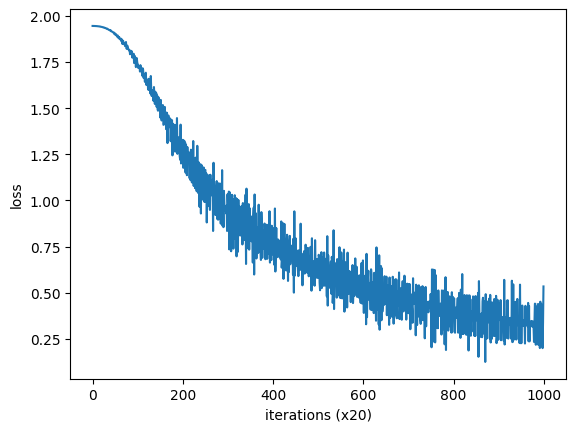

you [ 0.9454951  -0.91179353 -0.9283038  -1.638287    1.084348  ]
say [-1.1794207   1.2428573   1.209293   -0.34912586  1.21372   ]
goodbye [ 1.0658401 -1.0349848 -1.0791     0.5566607  0.8677478]
and [-0.5387714  1.0981712  1.0577732 -1.7731882  0.2625372]
i [ 1.0632269  -1.0355736  -1.0812685   0.5787797   0.85107887]
hello [ 0.9660481 -0.9279576 -0.9097396 -1.6643825  1.0609941]
. [-1.1954396  1.0025297  1.0108109  1.6488534  1.3655318]


In [18]:
# CBOWモデル学習用コードの実装
import sys

from common import trainer
sys.path.append("..")
from ch03.train import batch_size, hidden_size, optimizer
from common.trainer import Trainer
from common.optimizer import Adam
from simple_cbow import SimpleCBOW
from common.util import preprocess, create_contexts_target, convert_one_hot

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

In [ ]:
# CBOWモデルと確率
# skip-gramモデル
# カウントベース v.s. 推論ベース